# Leukemia (Golub 1999) dataset

This dataset comes from a proof-of-concept study published in 1999 by Golub et al. It showed how new cases of cancer could be classified by gene expression monitoring (via DNA microarray) and thereby provided a general approach for identifying new cancer classes and assigning tumors to known classes. These data were used to classify patients with acute myeloid leukemia (AML) and acute lymphoblastic leukemia (ALL).

In [1]:
# ── 0. Imports ─────────────────────────────────────────────────────────────────
import numpy as np
from sklearn.datasets import fetch_openml
 
from config.config import N_QUBITS, N_POINTS, N_TRIALS, N_EPOCH, N_POPSIZE, N_PM, SEED
from config.experiments import ExperimentConfig
 
from src.data.preprocessing import preprocess
import src.data.saving as saving
from src.data.saving import svm_exists, load_parameter_train, load_svm_results
from src.kernel.quantum_kernel import quantum_kernel_matrix_cross
from src.optimization.pipeline import get_candidate, get_svm_results
from src.optimization.classical_base import classical_baseline
import src.utils.visuals as visuals
from src.utils.visuals import plot_accuracy, plot_g_best, plot_kernel_heatmaps

from src.data.subsets import subset_random, subset_nystrom_global, subset_nystrom_stratified
from src.utils.visuals import graph_subset

In [2]:
# ── 1. Data ────────────────────────────────────────────────────────────────────

dataset = fetch_openml("leukemia", version=1, as_frame=False, parser="auto")
X = dataset.data.astype(float)
y = (dataset.target == "AML").astype(int)   # 0 = ALL, 1 = AML

X_train, X_test, y_train, y_test = preprocess(X, y, N_QUBITS)

print(f"Dataset  : {np.unique(dataset.target)}")
print(f"Train    : {X_train.shape}  |  Test: {X_test.shape}")

RESULTS_DIR = 'Results/Golub Leukemia dataset'
saving.RESULTS_DIR = RESULTS_DIR
visuals.RESULTS_DIR = RESULTS_DIR

Dataset  : ['ALL' 'AML']
Train    : (50, 4)  |  Test: (22, 4)


In [3]:
# ── 2. Experiments ─────────────────────────────────────────────────────────────
# This is the main section to edit. Each ExperimentConfig defines one run.
# Comment out any you don't want to include.
#
# name             → used as the Results subfolder name; must be unique
# optimizer        → 'optuna' or 'mealpy'
# subset_method    → 'random', 'nystrom_global', or 'nystrom_stratified'
# subset_kwargs    → passed to the chosen subset function
# optimizer_kwargs → passed to the chosen optimizer
# load_from        → (optional) load candidate from a different experiment name

EXPERIMENTS: list[ExperimentConfig] = [
 
    # ── OPTUNA ────────────────────────────────────────────────────────────────
    ExperimentConfig(
        name             = 'optuna_random',
        optimizer        = 'optuna',
        subset_method    = 'random',
        subset_kwargs    = {'n_sample': N_POINTS, 'seed': SEED},
        optimizer_kwargs = {'n_trials': N_TRIALS},
    ),
    ExperimentConfig(
        name             = 'optuna_nystrom_global',
        optimizer        = 'optuna',
        subset_method    = 'nystrom_global',
        subset_kwargs    = {'n_qubits': N_QUBITS, 'n_landmarks': N_POINTS},
        optimizer_kwargs = {'n_trials': N_TRIALS},
    ),
    ExperimentConfig(
        name             = 'optuna_nystrom_stratified',
        optimizer        = 'optuna',
        subset_method    = 'nystrom_stratified',
        subset_kwargs    = {'n_qubits': N_QUBITS, 'n_per_class': 10},
        optimizer_kwargs = {'n_trials': N_TRIALS},
    ),
    ExperimentConfig(
        name             = 'optuna_full',
        optimizer        = 'optuna',
        subset_method    = 'random',
        subset_kwargs    = {'n_sample': 50, 'seed': SEED},
        optimizer_kwargs = {'n_trials': N_TRIALS},
    ),
 
    # ── Mealpy ────────────────────────────────────────────────────────────────
    ExperimentConfig(
        name             = 'mealpy_random',
        optimizer        = 'mealpy',
        subset_method    = 'random',
        subset_kwargs    = {'n_sample': N_POINTS, 'seed': SEED},
        optimizer_kwargs = {'n_epoch': N_EPOCH, 'n_pop_size': N_POPSIZE, 'n_pm': N_PM},
    ),
    ExperimentConfig(
        name             = 'mealpy_nystrom_global',
        optimizer        = 'mealpy',
        subset_method    = 'nystrom_global',
        subset_kwargs    = {'n_qubits': N_QUBITS, 'n_landmarks': N_POINTS},
        optimizer_kwargs = {'n_epoch': N_EPOCH, 'n_pop_size': N_POPSIZE, 'n_pm': N_PM},
    ),
    ExperimentConfig(
        name             = 'mealpy_nystrom_stratified',
        optimizer        = 'mealpy',
        subset_method    = 'nystrom_stratified',
        subset_kwargs    = {'n_qubits': N_QUBITS, 'n_per_class': 10},
        optimizer_kwargs = {'n_epoch': N_EPOCH, 'n_pop_size': N_POPSIZE, 'n_pm': N_PM},
    ),
    ExperimentConfig(
        name             = 'mealpy_full',
        optimizer        = 'mealpy',
        subset_method    = 'random',
        subset_kwargs    = {'n_sample': 50, 'seed': SEED},
        optimizer_kwargs = {'n_epoch': N_EPOCH, 'n_pop_size': N_POPSIZE, 'n_pm': N_PM},
    ),
]

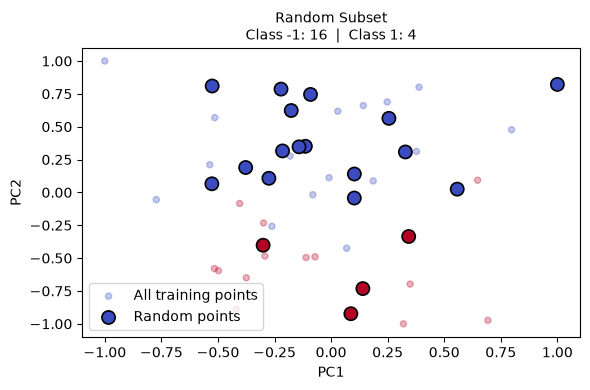

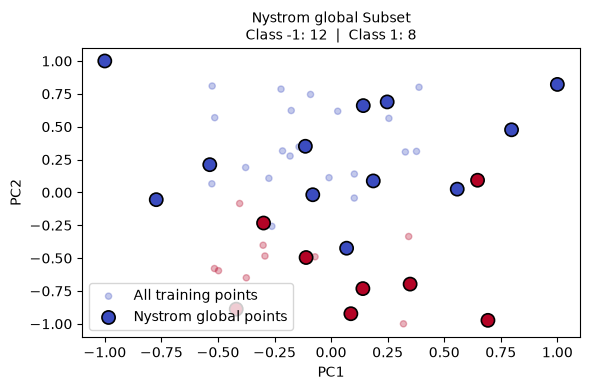

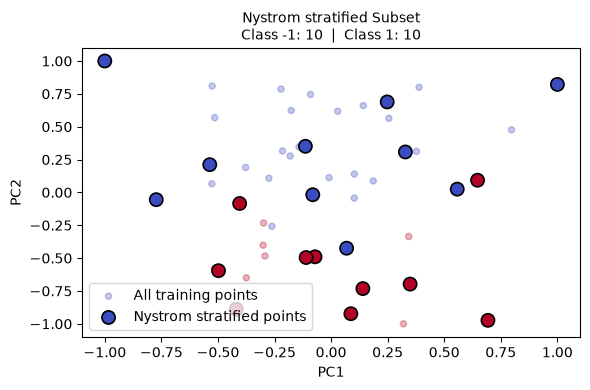

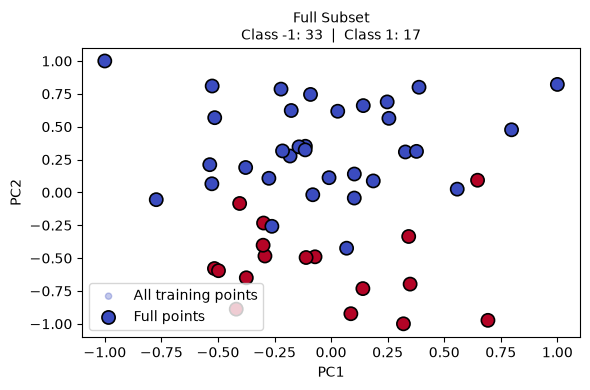

In [4]:
# Dataset structure
_, X_random, y_random = subset_random(X_train, y_train, N_POINTS, SEED)
graph_subset('Random', X_train, X_random, y_train, y_random)

_, X_global, y_global = subset_nystrom_global(X_train, y_train, N_QUBITS, N_POINTS)
graph_subset('Nystrom global', X_train, X_global, y_train, y_global)

_, X_stratified, y_stratified = subset_nystrom_stratified(X_train, y_train, N_QUBITS, 10)
graph_subset('Nystrom stratified', X_train, X_stratified, y_train, y_stratified)

_, X_random, y_random = subset_random(X_train, y_train, 50, SEED)
graph_subset('Full', X_train, X_random, y_train, y_random)

In [ ]:
# ── 3. Run ─────────────────────────────────────────────────────────────────────
# Cached results are reused automatically; delete Results/{name}/svm.pkl or
# Results/{name}/candidate.pkl to force a fresh run for that experiment.
 
summary = {}   # name → {accuracy, cv_acc, g_best, best_C}
 
# ── Classical baseline ──────────────────────────────────────────────────────
BASELINE = 'Classical_baseline'
if svm_exists(BASELINE):
    print(f"\nLoaded results of SVM for '{BASELINE}'")
    baseline_res = load_svm_results(BASELINE)
else:
    baseline_res = classical_baseline(X_train, y_train, X_test, y_test, name=BASELINE)
 
summary[BASELINE] = {
    'accuracy': baseline_res['accuracy'],
    'cv_acc':   float(baseline_res['best_cv_accuracy']),
    'best_C':   baseline_res['best_C'],
    'g_best':   float('nan'),
}
 
# ── Quantum experiments ─────────────────────────────────────────────────────
for config in EXPERIMENTS:
    print(f"\n{'─' * 60}")
    print(f" {config.name}  [{config.optimizer} + {config.subset_method}]")
    print(f"{'─' * 60}")
 
    # Step 1: Candidate (train or load from cache)
    candidate, K_train, K_classical, X_sub, y_sub = get_candidate(config, X_train, y_train)
    g_best = load_parameter_train(config.name).get('g_best', float('nan'))
 
    # Step 2: SVM (run or load from cache)
    K_test = None
    if not svm_exists(config.name):
        print("Computing cross-kernel (test × subset)…")
        K_test = quantum_kernel_matrix_cross(X_test, X_sub, candidate)
 
    results = get_svm_results(config, K_train, y_sub, K_test, y_test, cv=3)
 
    summary[config.name] = {
        'accuracy': results['accuracy'],
        'cv_acc':   float(results['best_cv_accuracy']),
        'best_C':   results['best_C'],
        'g_best':   g_best,
    }


Loaded results of SVM for 'Classical_baseline'

────────────────────────────────────────────────────────────
 optuna_random  [optuna + random]
────────────────────────────────────────────────────────────
Loading cached candidate for 'optuna_random'
[<src.circuit.genes.OptunaGene object at 0x123b3b560>, <src.circuit.genes.OptunaGene object at 0x1245ec7d0>, <src.circuit.genes.OptunaGene object at 0x1245ef6b0>, <src.circuit.genes.OptunaGene object at 0x1245ec080>, <src.circuit.genes.OptunaGene object at 0x1245ee150>, <src.circuit.genes.OptunaGene object at 0x1245ecda0>, <src.circuit.genes.OptunaGene object at 0x1245ee1e0>, <src.circuit.genes.OptunaGene object at 0x1245efb30>, <src.circuit.genes.OptunaGene object at 0x1245eca10>, <src.circuit.genes.OptunaGene object at 0x1245ece00>, <src.circuit.genes.OptunaGene object at 0x1245eca40>, <src.circuit.genes.OptunaGene object at 0x1245effb0>, <src.circuit.genes.OptunaGene object at 0x1245ef3e0>, <src.circuit.genes.OptunaGene object at 0x1245e

In [6]:
# ── 4. Summary table ───────────────────────────────────────────────────────────
 
def print_summary(summary: dict) -> None:
    W = 32
    print(f"\n{'═' * 75}")
    print(f"  {'EXPERIMENT':<{W}} {'TEST ACC':>9} {'CV ACC':>9} {'g_best':>9} {'best C':>6}")
    print(f"{'─' * 75}")
    for name, s in summary.items():
        g = f"{s['g_best']:9.2f}" if not np.isnan(s['g_best']) else f"{'—':>9}"
        print(f"  {name:<{W}} {s['accuracy']:>9.4f} {s['cv_acc']:>9.4f} {g} {s['best_C']:>6}")
    print(f"{'═' * 75}\n")
 
print_summary(summary)


═══════════════════════════════════════════════════════════════════════════
  EXPERIMENT                        TEST ACC    CV ACC    g_best best C
───────────────────────────────────────────────────────────────────────────
  Classical_baseline                  0.9545    0.9800         —      1
  optuna_random                       0.9545    0.9524     22.16      1
  optuna_nystrom_global               0.3636    0.5476      5.47      1
  optuna_nystrom_stratified           0.5000    0.4444      7.10     10
  optuna_full                         0.5000    0.5313     58.33      1
  mealpy_random                       0.4545    0.5635     13.24      1
  mealpy_nystrom_global               0.6364    0.4921      5.61    0.1
  mealpy_nystrom_stratified           0.5909    0.3413      7.57      1
  mealpy_full                         0.3636    0.3586     32.36    0.1
═══════════════════════════════════════════════════════════════════════════



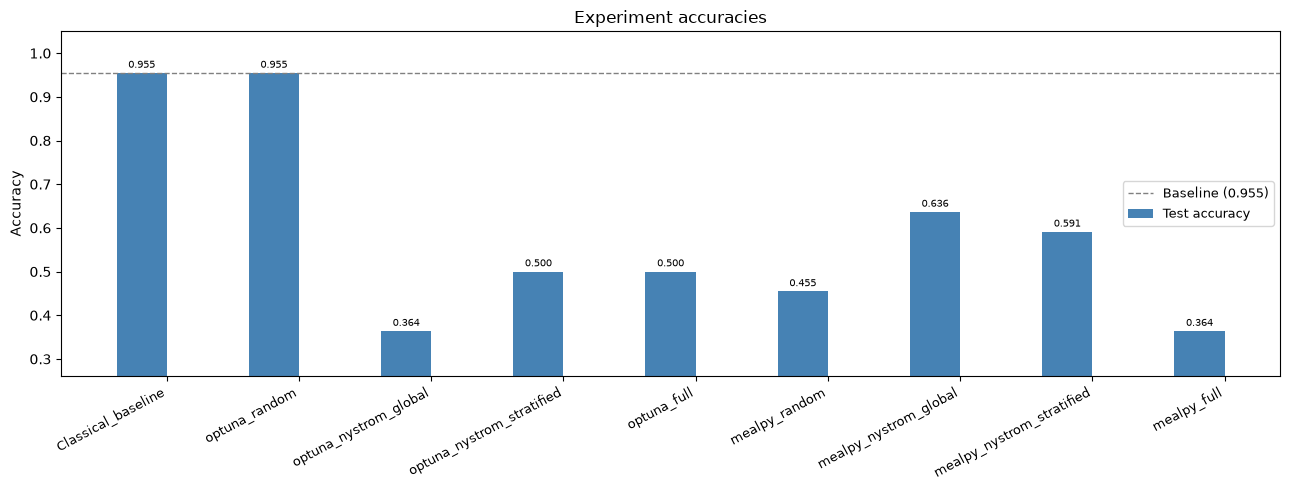

Saved → Results/Golub Leukemia dataset/accuracy_comparison.png


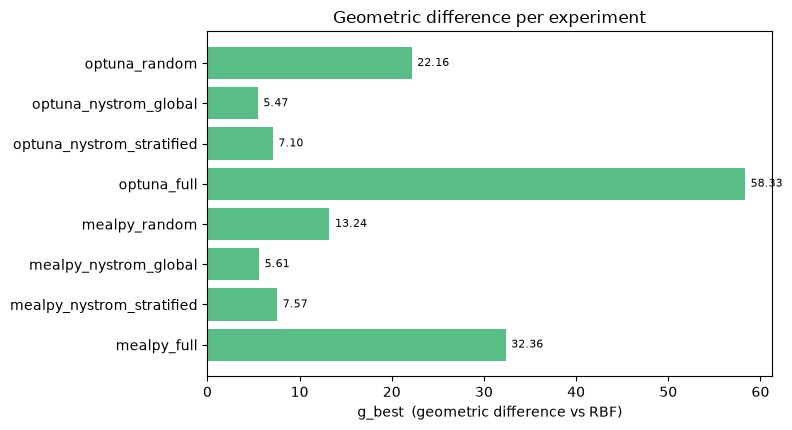

Saved → Results/Golub Leukemia dataset/g_best_comparison.png


In [9]:
# ── 5. Visualizations ──────────────────────────────────────────────────────────

plot_accuracy(summary, ['test'])
plot_g_best(summary)

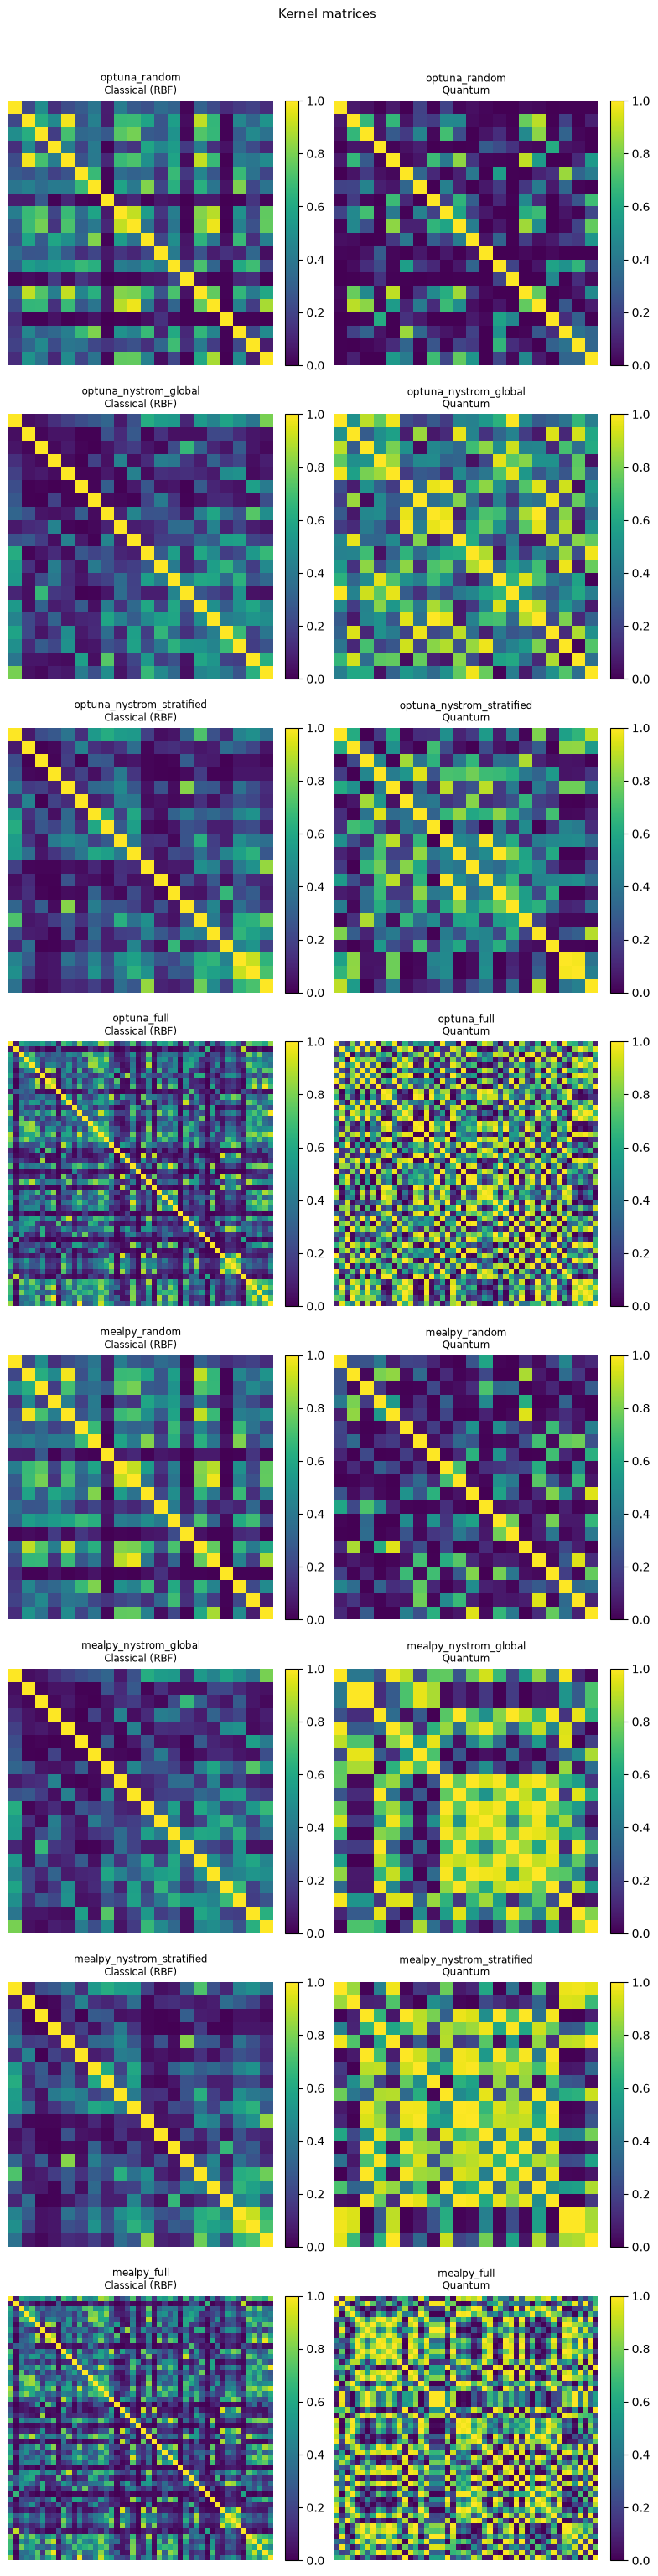

Saved → Results/Golub Leukemia dataset/kernel_heatmaps.png


In [10]:
plot_kernel_heatmaps(summary)